**Read JSON file**

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import StructType, StringType, StructField, NumericType, TimestampType, DateType
import pandas as pd
import matplotlib.pyplot as plt

spark = SparkSession.builder.appName("ReadAndFlattenJSON").getOrCreate()

df = spark.read.format("json").load("cc_sample_transaction.json")
df.show()


+----------+------+-------------+-----------+-------------------+--------+----------------+----------------------+------------------+------------------+-------------+--------------------+--------------------+---------------------+--------------------+
|Unnamed: 0|   amt|     category|     cc_bic|             cc_num|is_fraud|  merch_eff_time|merch_last_update_time|         merch_lat|        merch_long|merch_zipcode|            merchant|     personal_detail|trans_date_trans_time|           trans_num|
+----------+------+-------------+-----------+-------------------+--------+----------------+----------------------+------------------+------------------+-------------+--------------------+--------------------+---------------------+--------------------+
|         0|  4.97|     misc_net|CITIUS33CHI|   2703186189652095|       0|1325376018798532|         1325376018666|         36.011293|        -82.048315|        28705|fraud_Rippin, Kub...|{"person_name":"J...|  2019-01-01 00:00:18|0b242abb623afc

In [2]:
df.printSchema()

root
 |-- Unnamed: 0: string (nullable = true)
 |-- amt: string (nullable = true)
 |-- category: string (nullable = true)
 |-- cc_bic: string (nullable = true)
 |-- cc_num: string (nullable = true)
 |-- is_fraud: string (nullable = true)
 |-- merch_eff_time: string (nullable = true)
 |-- merch_last_update_time: string (nullable = true)
 |-- merch_lat: string (nullable = true)
 |-- merch_long: string (nullable = true)
 |-- merch_zipcode: string (nullable = true)
 |-- merchant: string (nullable = true)
 |-- personal_detail: string (nullable = true)
 |-- trans_date_trans_time: string (nullable = true)
 |-- trans_num: string (nullable = true)



**Data Quality Assurance**

1. Incorrect data types
Numeric fields like "amt", "merch_lat", "merch_long", "merch_eff_time" and "merch_last_update_time" are stored as strings.

"personal_detail" is a JSON string embedded as a string — it needs parsing.

"merch_eff_time" and "merch_last_update_time" are large integers likely representing timestamps.

2. Malformed nested JSON
The "personal_detail" field and "address" field inside it needs to be parsed considering it to be JSON strings.

3. Inconsistent formatting
"person_name" values are mixed with unwanted characters which needs to be processed and cleaned.

"is_fraud" is a string "0" instead of integer 0 or boolean False.

4. Missing or null values:
Must check for empty strings, nulls in other records.

In [3]:
## Checking if there are any null values in all columns
df.select([
    count(when(col(c).isNull() | (col(c) == "") | (col(c) == " "), c)).alias(c)
    for c in df.columns
]).show()


+----------+---+--------+------+------+--------+--------------+----------------------+---------+----------+-------------+--------+---------------+---------------------+---------+
|Unnamed: 0|amt|category|cc_bic|cc_num|is_fraud|merch_eff_time|merch_last_update_time|merch_lat|merch_long|merch_zipcode|merchant|personal_detail|trans_date_trans_time|trans_num|
+----------+---+--------+------+------+--------+--------------+----------------------+---------+----------+-------------+--------+---------------+---------------------+---------+
|         0|  0|       0|144381|     0|       0|             0|                     0|        0|         0|       195973|       0|              0|                    0|        0|
+----------+---+--------+------+------+--------+--------------+----------------------+---------+----------+-------------+--------+---------------+---------------------+---------+



For numeric columns, imputes with mean.

For string columns, imputes with the mode (most frequent value).

For timestamp/date/datetime columns, imputes with the latest (max) timestamp.

In [4]:
schema = df.schema

numeric_cols = [f.name for f in schema if isinstance(f.dataType, NumericType)]
string_cols = [f.name for f in schema if isinstance(f.dataType, StringType)]
timestamp_cols = [f.name for f in schema if isinstance(f.dataType, (TimestampType, DateType))]

numeric_impute = {}
for col_name in numeric_cols:
    mean_val = df.select(mean(col(col_name))).first()[0]
    if mean_val is not None:
        numeric_impute[col_name] = mean_val


def get_mode(df, col_name):
    mode_row = (
        df.groupBy(col_name)
        .count()
        .orderBy(desc("count"))
        .filter(col(col_name).isNotNull())
        .first()
    )
    return mode_row[0] if mode_row else None

string_impute = {}
for col_name in string_cols:
    mode_val = get_mode(df, col_name)
    if mode_val is not None:
        string_impute[col_name] = mode_val


timestamp_impute = {}
for col_name in timestamp_cols:
    max_val = df.select(max(col(col_name))).first()[0]
    if max_val is not None:
        timestamp_impute[col_name] = max_val


impute_dict = {}
impute_dict.update(numeric_impute)
impute_dict.update(string_impute)
impute_dict.update(timestamp_impute)


df_imputed = df.fillna(impute_dict).withColumn("cc_bic", regexp_replace(col(col_name), "(?i)^(null|na)$", string_impute.get("cc_bic")))
df = df_imputed

In [5]:
## This is to do direct type casting on columns that are not structure or nested structures
df = df.withColumn("amt", round(col("amt").cast("double"),2)) \
       .withColumn("merch_lat", round(col("merch_lat").cast("double"),4)) \
       .withColumn("merch_long", round(col("merch_long").cast("double"),4)) \
       .withColumn("is_fraud", col("is_fraud").cast("int"))
      #  .withColumn("lat", round(col("merch_lat").cast("double"),4)) \  ## Should be added after flattening has been done
      #  .withColumn("long", round(col("merch_long").cast("double"),4))  ## Should be added after flattening has been done


**This part deals with identifying and flattening data nature of structures and nested structures**

In [6]:
address_schema = StructType([
    StructField("street", StringType(), True),
    StructField("city", StringType(), True),
    StructField("state", StringType(), True),
    StructField("zip", StringType(), True)
])

personal_detail_schema = StructType([
    StructField("person_name", StringType(), True),
    StructField("gender", StringType(), True),
    StructField("address", StringType(), True),
    StructField("lat", StringType(), True),
    StructField("long", StringType(), True),
    StructField("city_pop", StringType(), True),
    StructField("job", StringType(), True),
    StructField("dob", StringType(), True)
])



df = df.withColumn("personal_detail_parsed", from_json(col("personal_detail"), personal_detail_schema)) \
      .withColumn("address_parsed", from_json(col("personal_detail_parsed.address"), address_schema))


df.printSchema()
df.select("personal_detail_parsed").show(truncate=False)


root
 |-- Unnamed: 0: string (nullable = false)
 |-- amt: double (nullable = true)
 |-- category: string (nullable = false)
 |-- cc_bic: string (nullable = false)
 |-- cc_num: string (nullable = false)
 |-- is_fraud: integer (nullable = true)
 |-- merch_eff_time: string (nullable = false)
 |-- merch_last_update_time: string (nullable = false)
 |-- merch_lat: double (nullable = true)
 |-- merch_long: double (nullable = true)
 |-- merch_zipcode: string (nullable = false)
 |-- merchant: string (nullable = false)
 |-- personal_detail: string (nullable = false)
 |-- trans_date_trans_time: string (nullable = false)
 |-- trans_num: string (nullable = false)
 |-- personal_detail_parsed: struct (nullable = true)
 |    |-- person_name: string (nullable = true)
 |    |-- gender: string (nullable = true)
 |    |-- address: string (nullable = true)
 |    |-- lat: string (nullable = true)
 |    |-- long: string (nullable = true)
 |    |-- city_pop: string (nullable = true)
 |    |-- job: string (nul

In [7]:
df_flat = df.select(
    "*",
    col("personal_detail_parsed.person_name").alias("person_name"),
    col("personal_detail_parsed.gender").alias("gender"),
    col("address_parsed.street").alias("street"),
    col("address_parsed.city").alias("city"),
    col("address_parsed.state").alias("state"),
    col("address_parsed.zip").alias("zip"),
    col("personal_detail_parsed.lat").alias("lat"),
    col("personal_detail_parsed.long").alias("long"),
    col("personal_detail_parsed.city_pop").alias("city_pop"),
    col("personal_detail_parsed.job").alias("job"),
    col("personal_detail_parsed.dob").alias("dob")
).drop("personal_detail", "personal_detail_parsed", "address_parsed")

df_flat.show(truncate=False)

+----------+------+-------------+--------------------------------+-------------------+--------+----------------+----------------------+---------+----------+-------------+----------------------------------------+---------------------+--------------------------------+-------------------------+------+------------------------------+------------------------+-----+-----+-------+------------------+--------+---------------------------------------------+----------+
|Unnamed: 0|amt   |category     |cc_bic                          |cc_num             |is_fraud|merch_eff_time  |merch_last_update_time|merch_lat|merch_long|merch_zipcode|merchant                                |trans_date_trans_time|trans_num                       |person_name              |gender|street                        |city                    |state|zip  |lat    |long              |city_pop|job                                          |dob       |
+----------+------+-------------+--------------------------------+------------

**Timestamp Conversion**

In [8]:
df_flat = df_flat.withColumn(
    "trans_date_trans_time",
    to_timestamp("trans_date_trans_time", "yyyy-MM-dd HH:mm:ss")
).withColumn(
    "merch_eff_time",
    from_unixtime((col("merch_eff_time").cast("double") / 1_000_000).cast("long"), "yyyy-MM-dd HH:mm:ss")
).withColumn(
    "merch_last_update_time",
    from_unixtime((col("merch_last_update_time").cast("double") / 1_000_000).cast("long"), "yyyy-MM-dd HH:mm:ss")
)

df_flat.show(truncate=False)

+----------+------+-------------+--------------------------------+-------------------+--------+-------------------+----------------------+---------+----------+-------------+----------------------------------------+---------------------+--------------------------------+-------------------------+------+------------------------------+------------------------+-----+-----+-------+------------------+--------+---------------------------------------------+----------+
|Unnamed: 0|amt   |category     |cc_bic                          |cc_num             |is_fraud|merch_eff_time     |merch_last_update_time|merch_lat|merch_long|merch_zipcode|merchant                                |trans_date_trans_time|trans_num                       |person_name              |gender|street                        |city                    |state|zip  |lat    |long              |city_pop|job                                          |dob       |
+----------+------+-------------+--------------------------------+------

**Name Derivation**

In [9]:
df_flat = df_flat.withColumn("job", split(col("job"), ",")) # This part do text cleaning as there might be two types of professional stated

df_flat = df_flat.withColumn("first_job", initcap(col("job")[0])) \
           .withColumn("second_job", initcap(trim(col("job")[1])))

In [10]:
## This is to check what kind of potential unwated characters or pattern in the column
df_flat.select(col('person_name')).distinct().show(truncate=False)

+------------------------+
|person_name             |
+------------------------+
|Jeffrey@Rice            |
|Aaron,Pena,eeeee        |
|Andrea@Cruz             |
|Ryan|Johnson!!!         |
|Susan|Hardy!!!          |
|Monique|Martin!!!       |
|Matthew/Lambert, !      |
|George/Floyd, !         |
|Allen/Bell, !           |
|Jessica@Perez           |
|Cristian,Jones,eeeee    |
|Casey, Howell           |
|Roberta@Mccarthy        |
|Candice|Brown!!!        |
|James@Reese             |
|Danielle|Yu!!!          |
|Kenneth, Sanchez        |
|Amanda, , Jones NOOOO   |
|Christopher, Luna       |
|Christopher/Patterson, !|
+------------------------+
only showing top 20 rows



In [11]:
## This part tends to clean as much as possible of dirty data
dirty_condition = col("person_name").rlike(r"[,@/|!]|ee+ee|NOOOO")


df_cleaned = df_flat.withColumn(
    "person_name",
    when(dirty_condition,
         regexp_replace(
             regexp_replace(
                 regexp_replace(col("person_name"), r"[,@/|!]", " "),  # special chars → space
             r"ee+ee|NOOOO", "")                                   # remove junk words
         , ",", " ")                                              # commas → space
    ).otherwise(col("person_name"))
)


df_cleaned = df_cleaned.withColumn("person_name", trim(col("person_name"))).withColumn("person_name", split(col("person_name"), " "))

df_cleaned = df_cleaned.withColumn("first_name", element_at(col("person_name"), 1)).withColumn("last_name", when(size(col("person_name")) > 1, element_at(col("person_name"), -1)))


df_cleaned.select("person_name", "first_name", "last_name").show(truncate=False)

+-------------------------+-----------+---------+
|person_name              |first_name |last_name|
+-------------------------+-----------+---------+
|[Jennifer, Banks]        |Jennifer   |Banks    |
|[Stephanie, Gill]        |Stephanie  |Gill     |
|[Edward, Sanchez]        |Edward     |Sanchez  |
|[Jeremy, White]          |Jeremy     |White    |
|[Tyler, Garcia]          |Tyler      |Garcia   |
|[Jennifer, Conner]       |Jennifer   |Conner   |
|[Kelsey, , , , Richards] |Kelsey     |Richards |
|[Steven, , Williams]     |Steven     |Williams |
|[Heather, , , , Chase]   |Heather    |Chase    |
|[Melissa, Aguilar]       |Melissa    |Aguilar  |
|[Eddie, Mendez]          |Eddie      |Mendez   |
|[Theresa, Blackwell]     |Theresa    |Blackwell|
|[Charles, Robles]        |Charles    |Robles   |
|[Jack, Hill]             |Jack       |Hill     |
|[Christopher, Castaneda] |Christopher|Castaneda|
|[Ronald, Carson]         |Ronald     |Carson   |
|[Lisa, , Mendez]         |Lisa       |Mendez   |


In [12]:
df_cleaned.select(col("first_name"), col("last_name")).distinct().show()

+-----------+-----------+
| first_name|  last_name|
+-----------+-----------+
|      Tammy|      Ayers|
|   Jennifer|      Vance|
|      Laura|      Johns|
|Christopher|    Gregory|
|   Kimberly|     Martin|
|      Chris|      White|
|     Angela|       West|
|     Steven|     Brooks|
|      Bobby|      Smith|
|     Ashley|   Mcdonald|
|       Jose|   Campbell|
|     Rachel|       Lowe|
|       Lisa|Fitzpatrick|
| Jacqueline|      Allen|
|   Jonathan|     Castro|
|    Vincent|    Mueller|
|      Susan|  Hernandez|
|     Sydney|    Montoya|
|    Monique|        Fox|
|Christopher|      White|
+-----------+-----------+
only showing top 20 rows



**Handling PII Data**

Approach i would follow:
Encryption -> Flexibility to hash data without permanent irreversibility

In [13]:
## Try to encrypt using pyspark in-built function
def encrypt_pii_columns(df, pii_cols, encryption_key, drop_original=True):

    encrypted_df = df
    for c in pii_cols:
        encrypted_df = encrypted_df.withColumn(c, base64(aes_encrypt(col(c).cast("string"), lit(encryption_key))))

    return encrypted_df


key = "TestingSecretKey"
pii_columns = ["cc_bic", "cc_num", "street", "city", "first_name", "lat", "long", "dob", "first_name", "last_name"]
df_encrypted = encrypt_pii_columns(df_cleaned, pii_columns, key)
df_encrypted.show(truncate=False)


+----------+------+-------------+------------------------------------------------------------------------------------+----------------------------------------------------------------+--------+-------------------+----------------------+---------+----------+-------------+----------------------------------------+---------------------+--------------------------------+-------------------------+------+------------------------------------------------------------------------------------+------------------------------------------------------------------------+-----+-----+------------------------------------------------+----------------------------------------------------------------+--------+------------------------------------------------+----------------------------------------------------+---------------------------------+-----------------------+----------------------------------------------------------------------------------------------------------------+-----------------------------------

In [14]:
## Try to encrypt using pyspark in-built function
def decrypt_pii_columns(df, encrypted_cols, encryption_key):

    decrypted_df = df
    for c in encrypted_cols:
        decrypted_df = decrypted_df.withColumn(c, aes_decrypt(unbase64(col(c)), lit(encryption_key)).cast(StringType()))

    return decrypted_df


df_decrypted = decrypt_pii_columns(df_encrypted, pii_columns, key)
df_decrypted.show(truncate=False)

+----------+------+-------------+--------------------------------+-------------------+--------+-------------------+----------------------+---------+----------+-------------+----------------------------------------+---------------------+--------------------------------+-------------------------+------+------------------------------+------------------------+-----+-----+-------+------------------+--------+------------------------------------------------+----------+---------------------------------+-----------------------+-----------+---------+
|Unnamed: 0|amt   |category     |cc_bic                          |cc_num             |is_fraud|merch_eff_time     |merch_last_update_time|merch_lat|merch_long|merch_zipcode|merchant                                |trans_date_trans_time|trans_num                       |person_name              |gender|street                        |city                    |state|zip  |lat    |long              |city_pop|job                                            

In [15]:
df_cleaned = df_encrypted.select(
    col("Unnamed: 0"),
    col("trans_date_trans_time"),
    col("cc_num"),
    col("merchant"),
    col("category"),
    col("amt"),
    col("first_name"),
    col("last_name"),
    col("gender"),
    col("street"),
    col("city"),
    col("state"),
    col("zip"),
    col("lat"),
    col("long"),
    col("city_pop"),
    col("job"),
    col("dob"),
    col("trans_num"),
    col("merch_lat"),
    col("merch_long"),
    col("is_fraud"),
    col("merch_zipcode"),
    col("merch_last_update_time"),
    col("merch_eff_time"),
    col("cc_bic")

)

**Visualization/Analysis**

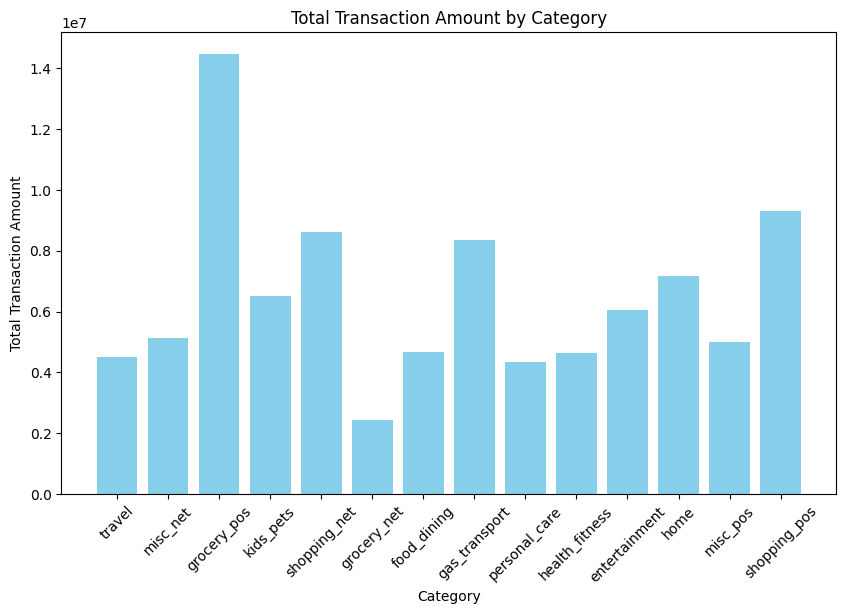

In [16]:

# 1. Total transaction amount by category
agg_amt_cat = df_cleaned.groupBy("category").sum("amt").withColumnRenamed("sum(amt)", "total_amt")
pdf_amt_cat = agg_amt_cat.toPandas()

plt.figure(figsize=(10,6))
plt.bar(pdf_amt_cat['category'], pdf_amt_cat['total_amt'], color='skyblue')
plt.xlabel('Category')
plt.ylabel('Total Transaction Amount')
plt.title('Total Transaction Amount by Category')
plt.xticks(rotation=45)
plt.show()

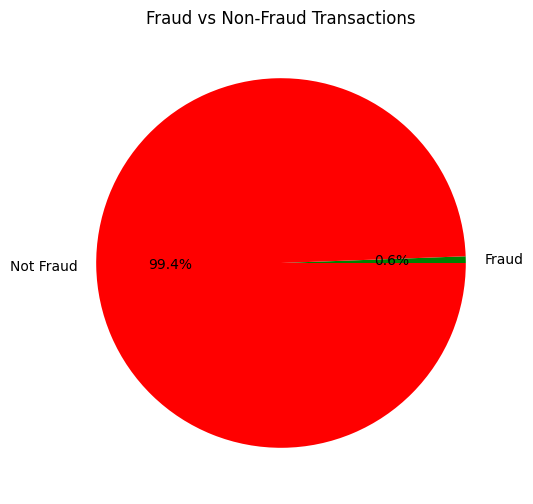

In [17]:
#2. Fraud count
fraud_counts = df_cleaned.groupBy("is_fraud").count().toPandas()

plt.figure(figsize=(6,6))
plt.pie(fraud_counts['count'], labels=fraud_counts['is_fraud'].map({0: 'Not Fraud', 1: 'Fraud'}), autopct='%1.1f%%', colors=['green', 'red'])
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()


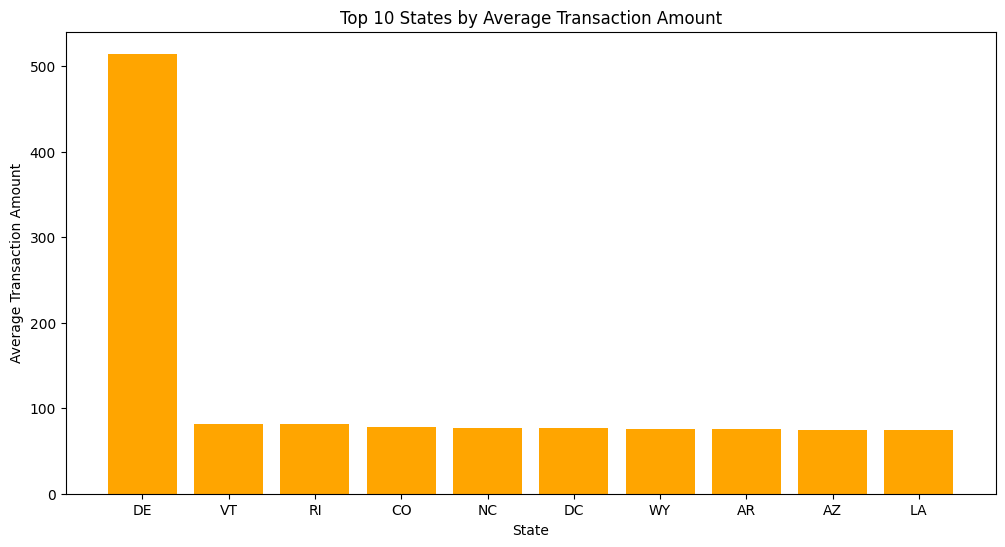

In [18]:
# 3. Average transaction amount by state (top 10 states)
avg_amt_state = df_cleaned.groupBy("state").avg("amt").withColumnRenamed("avg(amt)", "avg_amt")
top_avg_amt_state = avg_amt_state.orderBy("avg_amt", ascending=False).limit(10).toPandas()

plt.figure(figsize=(12,6))
plt.bar(top_avg_amt_state['state'], top_avg_amt_state['avg_amt'], color='orange')
plt.xlabel('State')
plt.ylabel('Average Transaction Amount')
plt.title('Top 10 States by Average Transaction Amount')
plt.show()

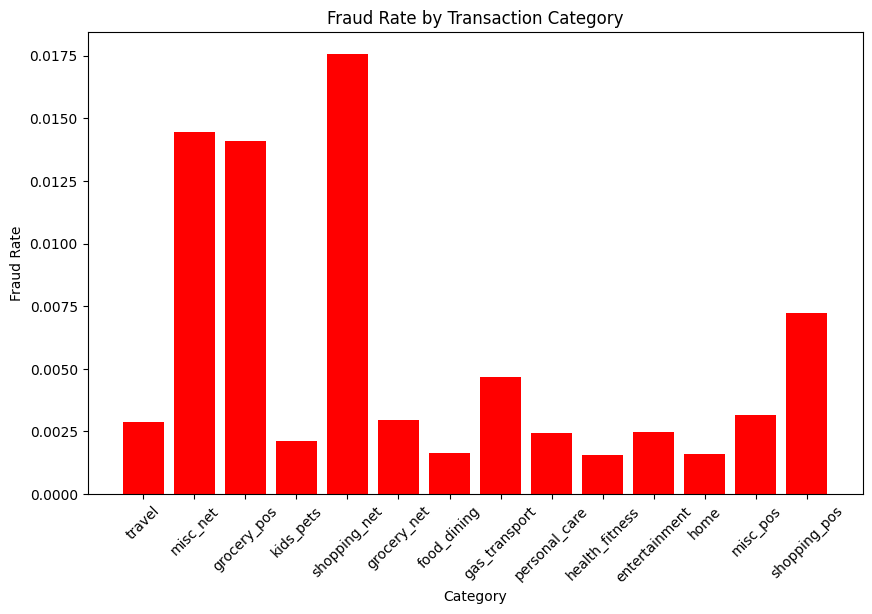

In [19]:
# 4. Fraud rate by category
fraud_rate_cat = df_cleaned.groupBy("category").agg(avg(col("is_fraud")).alias("fraud_rate"))
pdf_fraud_rate = fraud_rate_cat.toPandas()

plt.figure(figsize=(10,6))
plt.bar(pdf_fraud_rate['category'], pdf_fraud_rate['fraud_rate'], color='red')
plt.xlabel('Category')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Transaction Category')
plt.xticks(rotation=45)
plt.show()